<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-failure-prediction/blob/main/Modelling_RNN_and_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook contains code for model training, testing and parameter tuning for the RNN and LSTM models.

# Import Data and Packages

In [ ]:
import torch.nn as nn
from google.colab import drive
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as statistics
import keras
from keras import models
from keras import layers

In [ ]:
# Import drive

drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


In [ ]:
# Import data

X_train_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/X_train_sequential.csv", encoding = "latin1")
y_train_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/y_train_sequential.csv", encoding = "latin1")

X_valid_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/X_valid_sequential.csv", encoding = "latin1")
y_valid_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/y_valid_sequential.csv", encoding = "latin1")

X_test_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/X_test_sequential.csv", encoding = "latin1")
y_test_sequential = pd.read_csv("/content/drive/MyDrive/MSc project/y_test_sequential.csv", encoding = "latin1")


# Manipulate data

Some minor changes to the data are required to prepare for modelling. Data needs to be transformed to tidy data format and tensor strcuture.

In [ ]:
# convert categorical columns

X_train_sequential['Lining'] = X_train_sequential['Lining'].astype("category")
X_train_sequential['Surface'] = X_train_sequential['Surface'].astype("category")
X_train_sequential['Soil'] = X_train_sequential['Soil'].astype("category")
X_train_sequential['Material'] = X_train_sequential['Material'].astype("category")

X_valid_sequential['Lining'] = X_valid_sequential['Lining'].astype("category")
X_valid_sequential['Surface'] = X_valid_sequential['Surface'].astype("category")
X_valid_sequential['Soil'] = X_valid_sequential['Soil'].astype("category")
X_valid_sequential['Material'] = X_valid_sequential['Material'].astype("category")

X_test_sequential['Lining'] = X_test_sequential['Lining'].astype("category")
X_test_sequential['Surface'] = X_test_sequential['Surface'].astype("category")
X_test_sequential['Soil'] = X_test_sequential['Soil'].astype("category")
X_test_sequential['Material'] = X_test_sequential['Material'].astype("category")


In [ ]:
# normalise data

scaler = StandardScaler()

for feature in X_train_sequential[["Diameter", "Length", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Age", "Previous bursts"]]:
  X_train_sequential[feature] = scaler.fit_transform(X_train_sequential[[feature]])

for feature in X_valid_sequential[["Diameter", "Length", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Age", "Previous bursts"]]:
  X_valid_sequential[feature] = scaler.fit_transform(X_valid_sequential[[feature]])

for feature in X_test_sequential[["Diameter", "Length", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Age", "Previous bursts"]]:
  X_test_sequential[feature] = scaler.fit_transform(X_test_sequential[[feature]])

In [ ]:
# filter response vector to contain only result for latest burst

index = X_train_sequential.groupby("Asset.ID")["Age"].nlargest(1).reset_index(level = 0, drop = True).index
y_train_sequential_tidy = y_train_sequential.loc[index]

index = X_valid_sequential.groupby("Asset.ID")["Age"].nlargest(1).reset_index(level = 0, drop = True).index
y_valid_sequential_tidy = y_valid_sequential.loc[index]

index = X_test_sequential.groupby("Asset.ID")["Age"].nlargest(1).reset_index(level = 0, drop = True).index
y_test_sequential_tidy = y_test_sequential.loc[index]

In [ ]:
# remove asset ID

X_train_sequential = X_train_sequential.drop("Asset.ID", axis = 1)
X_valid_sequential = X_valid_sequential.drop("Asset.ID", axis = 1)
X_test_sequential = X_test_sequential.drop("Asset.ID", axis = 1)

In [ ]:
# convert to tidy data

X_train_sequential_tidy = pd.get_dummies(X_train_sequential)
X_valid_sequential_tidy = pd.get_dummies(X_valid_sequential)
X_test_sequential_tidy = pd.get_dummies(X_test_sequential)


In [ ]:
# add empty columns for missing categories to the test and valid data (required for model testing and validation)

X_test_sequential_tidy["Material_Steel"] = 0
X_test_sequential_tidy["Material_Steel"] = X_test_sequential_tidy["Material_Steel"].astype(bool)
X_test_sequential_tidy["Lining_PRESENT"] = 0
X_test_sequential_tidy["Lining_PRESENT"] = X_test_sequential_tidy["Lining_PRESENT"].astype(bool)

X_valid_sequential_tidy["Material_Ductile_Iron"] = 0
X_valid_sequential_tidy["Material_Ductile_Iron"] = X_valid_sequential_tidy["Material_Ductile_Iron"].astype(bool)

In [ ]:
# convert data frame to numpy array
X_train_numpy = X_train_sequential_tidy.to_numpy(dtype = np.float32)
X_valid_numpy = X_valid_sequential_tidy.to_numpy(dtype = np.float32)
X_test_numpy = X_test_sequential_tidy.to_numpy(dtype = np.float32)

In [ ]:
# convert numpy array to tensor

X_train_tensor = tf.convert_to_tensor(X_train_numpy)

X_valid_tensor = tf.convert_to_tensor(X_valid_numpy)

X_test_tensor = tf.convert_to_tensor(X_test_numpy)

In [ ]:
# adjust tensor shape

X_train_tensor = tf.reshape(X_train_tensor, (720, 5, 28))

X_valid_tensor = tf.reshape(X_valid_tensor, (29, 5, 28))

X_test_tensor = tf.reshape(X_test_tensor, (44, 5, 28))

# RNN

In this section, the RNN model is trained using default parameters.

In [ ]:
# Training RNN

keras.utils.set_random_seed(42)


model_RNN = models.Sequential([
    layers.SimpleRNN(
        units=16,
        input_shape=(5, 28),
        activation='tanh',
        return_sequences=False
    ),
    layers.Dense(1, activation='relu')
])

model_RNN.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', "root_mean_squared_error"]
)

model_RNN.summary()

# Train
history = model_RNN.fit(
    X_train_tensor,
    y_train_sequential_tidy,
    epochs=50,
    batch_size=32,
    validation_data = (X_valid_tensor, y_valid_sequential_tidy)
)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 16)             │           720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 12.0184 - mae: 2.0931 - root_mean_squared_error: 3.4667 - val_loss: 0.4350 - val_mae: 0.4758 - val_root_mean_squared_error: 0.6596
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 11.7175 - mae: 2.0689 - root_mean_squared_error: 3.4231 - val_loss: 0.4613 - val_mae: 0.4975 - val_root_mean_squared_error: 0.6792
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.2741 - mae: 2.0476 - root_mean_squared_error: 3.3577 - val_loss: 0.4834 - val_mae: 0.4997 - val_root_mean_squared_error: 0.6952
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.5965 - mae: 2.0307 - root_mean_squared_error: 3.2552 - val_loss: 0.5553 - val_mae: 0.5401 - val_root_mean_squared_error: 0.7452
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.2696 - mae: 2.0363 - root_mean_squared_error: 3.2046 - val_loss: 0.5968 - val_mae: 0.5687 - val_root_mean_squared_error: 0.7725
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - lo

The MAE and RMSE for testing dataset are computed using bootstrapping. The maximum residual error is also computed.

In [ ]:
# MAE for RNN

MAE_RNN = []

for i in range(1000):

    indices = tf.random.uniform(
    shape=(44,),
    minval=0,
    maxval=44,
    dtype=tf.int32
    )

    X_test_bootstrap = tf.gather(X_test_tensor, indices)

    y_test_bootstrap = y_test_sequential_tidy.iloc[indices]

    metrics = model_RNN.evaluate(X_test_bootstrap, y_test_bootstrap, verbose = 0)

    MAE_RNN.append(metrics[1])


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 497ms/step - loss: 2.0991 - mae: 1.0997 - root_mean_squared_error: 1.4488
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1.1523 - mae: 0.7382 - root_mean_squared_error: 1.0735
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.2742 - mae: 0.7268 - root_mean_squared_error: 1.1288
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.0044 - mae: 0.6177 - root_mean_squared_error: 1.0022
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.8420 - mae: 0.6276 - root_mean_squared_error: 0.9176
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 1.3263 - mae: 0.7733 - root_mean_squared_error: 1.1516
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.9850 - mae: 0.6623 - root_mean_squared_error: 0.9924
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1.7887 - mae: 1.0241 - root_mean_squared_error: 1.3374
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 1.3663 - mae: 0.8109 - root_mean_squared_error: 1.1689
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.3389 - mae: 0.8189 - root_mean_squared_err

In [ ]:
# RMSE for RNN

RMSE_RNN = []

for i in range(1000):

    indices = tf.random.uniform(
    shape=(44,),
    minval=0,
    maxval=44,
    dtype=tf.int32
    )

    X_test_bootstrap = tf.gather(X_test_tensor, indices)

    y_test_bootstrap = y_test_sequential_tidy.iloc[indices]

    metrics = model_RNN.evaluate(X_test_bootstrap, y_test_bootstrap, verbose = 0)

    RMSE_RNN.append(metrics[1])

In [ ]:
# max residual error
preds = model_RNN.predict(X_test_tensor, verbose=0)

print((y_test_sequential_tidy - preds).min())
print((y_test_sequential_tidy - preds).max())

Time-to-failure   -2.720056
dtype: float64
Time-to-failure    0.971541
dtype: float64


# LSTM

In this section, the LSTM model is trained using default parameters.

In [ ]:
keras.utils.set_random_seed(42)

model_LSTM = models.Sequential([
    layers.LSTM(units = 8,
                input_shape=(5, 28)),
    layers.Dense(1, activation = "relu")
])


model_LSTM.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', "root_mean_squared_error"]
)


model_LSTM.fit(
    X_train_tensor,
    y_train_sequential_tidy,
    epochs=50,
    batch_size=32
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 12.1319 - mae: 2.0362 - root_mean_squared_error: 3.4831
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.9071 - mae: 2.0080 - root_mean_squared_error: 3.4507
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.6358 - mae: 1.9768 - root_mean_squared_error: 3.4111
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.3387 - mae: 1.9540 - root_mean_squared_error: 3.3673
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.0539 - mae: 1.9423 - root_mean_squared_error: 3.3247
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.8096 - mae: 1.9418 - root_mean_squared_error: 3.2878
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.6129 - mae: 1.9467 - root_mean_squared_error: 3.2577
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10.4580 - mae: 1.9569 - root_mean_squared_error: 3.2339
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10.3406 - mae: 1.9680 - root_mean_squared

The MAE and RMSE metrics are computed using bootstrapping. The maximum residual error is also computed.

In [ ]:
# MAE for LSTM

MAE_LSTM = []

for i in range(1000):

    indices = tf.random.uniform(
    shape=(44,),
    minval=0,
    maxval=44,
    dtype=tf.int32
    )

    X_test_bootstrap = tf.gather(X_test_tensor, indices)

    y_test_bootstrap = y_test_sequential_tidy.iloc[indices]

    metrics = model_LSTM.evaluate(X_test_bootstrap, y_test_bootstrap, verbose = 0)

    MAE_LSTM.append(metrics[1])

In [ ]:
# RMSE for LSTM

RMSE_LSTM = []

for i in range(1000):

    indices = tf.random.uniform(
    shape=(44,),
    minval=0,
    maxval=44,
    dtype=tf.int32
    )

    X_test_bootstrap = tf.gather(X_test_tensor, indices)

    y_test_bootstrap = y_test_sequential_tidy.iloc[indices]

    metrics = model_LSTM.evaluate(X_test_bootstrap, y_test_bootstrap, verbose = 0)

    RMSE_LSTM.append(metrics[1])

In [ ]:
# maximum residual error

preds = model_LSTM.predict(X_test_tensor, verbose=0)

print((y_test_sequential_tidy - preds).min())
print((y_test_sequential_tidy - preds).max())

Time-to-failure   -3.022909
dtype: float64
Time-to-failure    1.29589
dtype: float64


In this section, the performance of LSTM is compared to baseline - RNN using a t-test and the metrics created using bootstrapping.

In [ ]:
t_test_MAE = stats.ttest_rel(MAE_RNN, MAE_LSTM)

print(t_test_MAE.statistic)
print(t_test_MAE.pvalue)
print(t_test_MAE.df)

[20.84120343]
[2.21029867e-80]
[999]


In [ ]:
t_test_RMSE = stats.ttest_rel(RMSE_RNN, RMSE_LSTM)

print(t_test_RMSE.statistic)
print(t_test_RMSE.pvalue)
print(t_test_RMSE.df)

[26.42634253]
[4.03851689e-117]
[999]


# Parameter tuning

In this section, parameter tuning is performed using iterative tuning for the best performing model from the previous section - LSTM.

In [ ]:
# parameter tuning

keras.utils.set_random_seed(42)

model_LSTM = models.Sequential([
    layers.LSTM(
        units=8,
        input_shape=(5, 28),
        activation='tanh',
        return_sequences=False
    ),
    layers.Dense(1, activation='relu')
])

optimiser = keras.optimizers.Adam(learning_rate=0.0003)

model_LSTM.compile(
    optimizer=optimiser,
    loss='mse',
    metrics=['mae', "root_mean_squared_error"]
)

model_LSTM.summary()

# Train
history = model_LSTM.fit(
    X_train_tensor,
    y_train_sequential_tidy,
    epochs=50,
    batch_size=256,
    validation_data = (X_valid_tensor, y_valid_sequential_tidy)
)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,193 (4.66 KB)

 Trainable params: 1,193 (4.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - loss: 11.7817 - mae: 2.0100 - root_mean_squared_error: 3.4325 - val_loss: 0.2871 - val_mae: 0.3368 - val_root_mean_squared_error: 0.5358
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 11.7648 - mae: 2.0081 - root_mean_squared_error: 3.4300 - val_loss: 0.2853 - val_mae: 0.3364 - val_root_mean_squared_error: 0.5342
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 11.7481 - mae: 2.0061 - root_mean_squared_error: 3.4275 - val_loss: 0.2836 - val_mae: 0.3360 - val_root_mean_squared_error: 0.5325
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 11.7313 - mae: 2.0042 - root_mean_squared_error: 3.4251 - val_loss: 0.2819 - val_mae: 0.3356 - val_root_mean_squared_error: 0.5310
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 11.7146 - mae: 2.0023 - root_mean_squared_error: 3.4227 - val_loss: 0.2803 - val_mae: 0.3352 - val_root_mean_squared_error: 0.5294
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 11

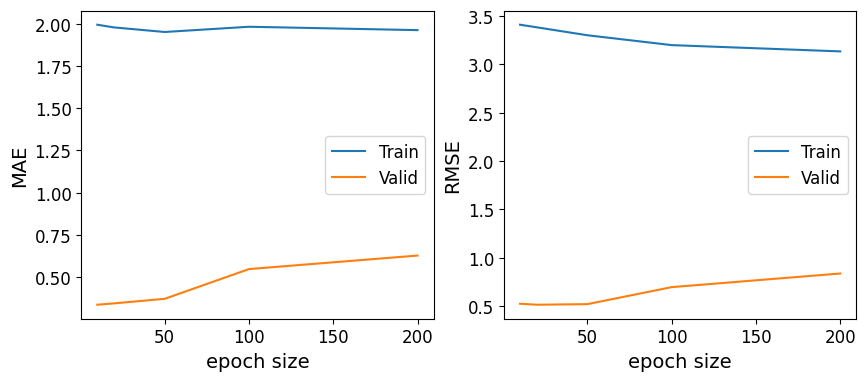

In [ ]:
# epoch size

epoch_size = [10, 20, 50, 100, 200]

MAE = [1.994, 1.978, 1.951, 1.982, 1.962 ]
RMSE = [3.410, 3.383, 3.301, 3.199, 3.134 ]

valid_MAE = [0.337, 0.345, 0.372, 0.548, 0.628]
valid_RMSE = [0.523, 0.513, 0.519, 0.695, 0.836]

fix, ax = plt.subplots(1,2, figsize = [10,4])

ax[0].plot(epoch_size, MAE, label = "Train")
ax[0].plot(epoch_size, valid_MAE, label = "Valid")
ax[0].legend(fontsize = 12)
ax[0].set_xlabel("epoch size", fontsize = 14)
ax[0].set_ylabel("MAE", fontsize = 14)
ax[0].tick_params(labelsize=12)

ax[1].plot(epoch_size, RMSE, label = "Train")
ax[1].plot(epoch_size, valid_RMSE, label = "Valid")
ax[1].legend(fontsize = 12)
ax[1].set_xlabel("epoch size", fontsize = 14)
ax[1].set_ylabel("RMSE", fontsize = 14)
ax[1].tick_params(labelsize = 12)



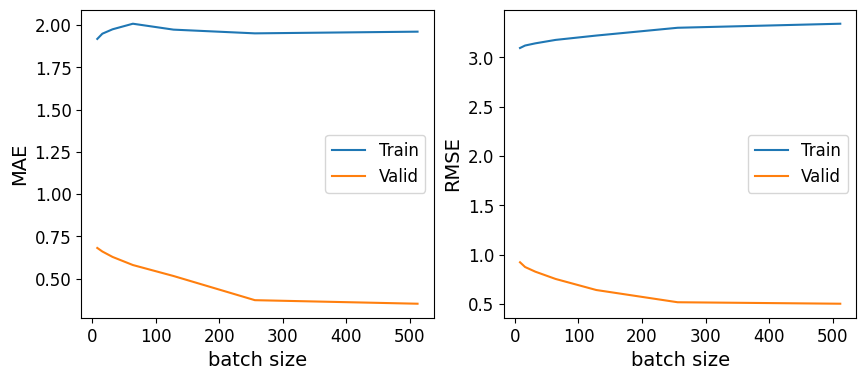

In [ ]:
# batch size



batch_size = [8, 16, 32, 64, 128, 256, 512]

MAE = [1.918, 1.949, 1.975, 2.008, 1.973, 1.951, 1.961 ]
RMSE = [3.096, 3.121, 3.143, 3.178, 3.222, 3.301, 3.342 ]

valid_MAE = [0.681, 0.660, 0.628, 0.58, 0.515, 0.372, 0.351]
valid_RMSE = [0.924, 0.876, 0.829, 0.755, 0.643, 0.519, 0.504]

fix, ax = plt.subplots(1,2, figsize = [10,4])

ax[0].plot(batch_size, MAE, label = "Train")
ax[0].plot(batch_size, valid_MAE, label = "Valid")
ax[0].legend(fontsize = 12)
ax[0].set_xlabel("batch size", fontsize = 14)
ax[0].set_ylabel("MAE", fontsize = 14)
ax[0].tick_params(labelsize=12)

ax[1].plot(batch_size, RMSE, label = "Train")
ax[1].plot(batch_size, valid_RMSE, label = "Valid")
ax[1].legend(fontsize = 12)
ax[1].set_xlabel("batch size", fontsize = 14)
ax[1].set_ylabel("RMSE", fontsize = 14)
ax[1].tick_params(labelsize = 12)




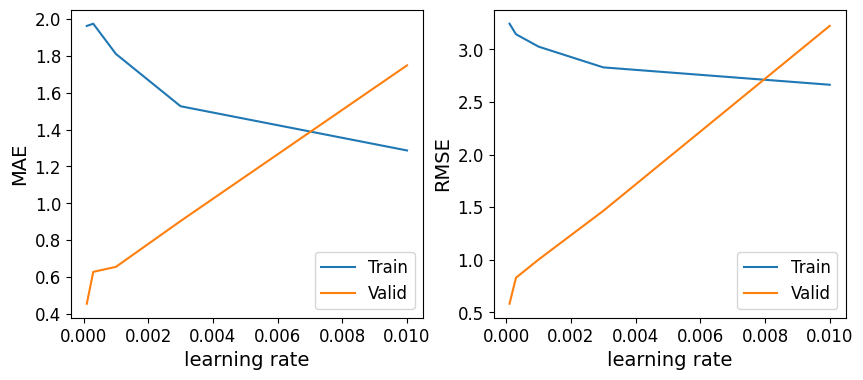

In [ ]:
# learning rate

eta = [0.0001, 0.0003, 0.001, 0.003, 0.01]

MAE = [1.963, 1.975 , 1.811, 1.527, 1.287]
RMSE = [3.243, 3.143, 3.025, 2.828, 2.663]

valid_MAE = [0.455, 0.628, 0.655, 0.904, 1.749]
valid_RMSE = [0.582, 0.829, 1.002, 1.465, 3.223]

fix, ax = plt.subplots(1,2, figsize = [10,4])

ax[0].plot(eta, MAE, label = "Train")
ax[0].plot(eta, valid_MAE, label = "Valid")
ax[0].legend(fontsize = 12)
ax[0].set_xlabel("learning rate", fontsize = 14)
ax[0].set_ylabel("MAE", fontsize = 14)
ax[0].tick_params(labelsize=12)

ax[1].plot(eta, RMSE, label = "Train")
ax[1].plot(eta, valid_RMSE, label = "Valid")
ax[1].legend(fontsize = 12)
ax[1].set_xlabel("learning rate", fontsize = 14)
ax[1].set_ylabel("RMSE", fontsize = 14)
ax[1].tick_params(labelsize = 12)




In [ ]:
# no. of hidden layers

hidden_layer = [2, 4, 8, 16, 32, 64, 128]

MAE = [1.980, 1.934, 1.811, 1.661, 1.415, 1.233, 1.233]
RMSE = [3.145, 3.104, 3.025, 2.875, 2.704, 2.629, 2.623 ]

valid_MAE = [0.667, 0.675, 0.655, 1.865, 1.060, 1.523, 1.102]
valid_RMSE = [0.879, 0.934, 1.002, 2.323, 1.741, 2.270, 2.001]

fix, ax = plt.subplots(1,2, figsize = [10,4])

ax[0].plot(hidden_layer, MAE, label = "Train")
ax[0].plot(hidden_layer, valid_MAE, label = "Valid")
ax[0].legend(fontsize = 12)
ax[0].set_xlabel("Hidden layer size", fontsize = 14)
ax[0].set_ylabel("MAE", fontsize = 14)
ax[0].tick_params(labelsize=12)

ax[1].plot(hidden_layer, RMSE, label = "Train")
ax[1].plot(hidden_layer, valid_RMSE, label = "Valid")
ax[1].legend(fontsize = 12)
ax[1].set_xlabel("Hidden layer size", fontsize = 14)
ax[1].set_ylabel("RMSE", fontsize = 14)
ax[1].tick_params(labelsize = 12)

NameError: name 'plt' is not defined

# Ablation Study

In this section, ablation study is conducted to decide on the importance of each feature for the LSTM model.

In [ ]:
# drop feature and convert to tensor (this is done for each feature before running the model in next cell)

X_train_sequential_feature = X_train_sequential.drop("Surface", axis = 1) # drop column with material
X_test_sequential_feature = X_test_sequential.drop("Surface", axis = 1)

X_train_sequential_tidy_feature = pd.get_dummies(X_train_sequential_feature) # get dummy variables
X_test_sequential_tidy_feature = pd.get_dummies(X_test_sequential_feature)


X_test_sequential_tidy_feature["Material_Steel"] = 0
X_test_sequential_tidy_feature["Material_Steel"] = X_test_sequential_tidy_feature["Material_Steel"].astype(bool)
X_test_sequential_tidy_feature["Lining_PRESENT"] = 0
X_test_sequential_tidy_feature["Lining_PRESENT"] = X_test_sequential_tidy["Lining_PRESENT"].astype(bool)


X_train_numpy_feature = X_train_sequential_tidy_feature.to_numpy(dtype = np.float32) # convert dataframe to array
X_test_numpy_feature = X_test_sequential_tidy_feature.to_numpy(dtype = np.float32)

X_train_tensor_feature = tf.convert_to_tensor(X_train_numpy_feature) # convert numpy array to tensor
X_test_tensor_feature = tf.convert_to_tensor(X_test_numpy_feature)


X_train_tensor_feature = tf.reshape(X_train_tensor_feature, (720, 5, 25)) # adjust tensor shape
X_test_tensor_feature = tf.reshape(X_test_tensor_feature, (44, 5, 25))


In [ ]:
# model testing

keras.utils.set_random_seed(42)


model_LSTM = models.Sequential([
    layers.LSTM(
        units=8,
        input_shape=(5, 28),
        activation='tanh',
        return_sequences=False
    ),
    layers.Dense(1, activation='relu')
])

optimiser = keras.optimizers.Adam(learning_rate=0.0003)

model_LSTM.compile(
    optimizer=optimiser,
    loss='mse',
    metrics=['mae', "root_mean_squared_error"]
)

model_LSTM.summary()

# Train
history = model_LSTM.fit(
    X_train_tensor,
    y_train_sequential_tidy,
    epochs=50,
    batch_size=256)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_23 (LSTM)                  │ (None, 8)              │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,193 (4.66 KB)

 Trainable params: 1,193 (4.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 12.0360 - mae: 2.0408 - root_mean_squared_error: 3.4693
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 12.0174 - mae: 2.0388 - root_mean_squared_error: 3.4666
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.9993 - mae: 2.0368 - root_mean_squared_error: 3.4640
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 11.9810 - mae: 2.0347 - root_mean_squared_error: 3.4614
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 11.9624 - mae: 2.0326 - root_mean_squared_error: 3.4587
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 11.9433 - mae: 2.0304 - root_mean_squared_error: 3.4559
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 11.9241 - mae: 2.0281 - root_mean_squared_error: 3.4531
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 11.9046 - mae: 2.0257 - root_mean_squared_error: 3.4503
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 11.8850 - mae: 2.0233 - root_mean_squar

In [ ]:
# evaluate model without feature at test

model_LSTM.evaluate(X_test_tensor, y_test_sequential_tidy) # MAE and RMSe

preds = model_LSTM.predict(X_test_tensor, verbose=0) # max residual error
print((y_test_sequential_tidy - preds).min())
print((y_test_sequential_tidy - preds).max())

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.2401 - mae: 0.3618 - root_mean_squared_error: 0.4900
Time-to-failure   -1.099957
dtype: float64
Time-to-failure    1.29589
dtype: float64


# Further evaluation

In this section, failure analysis of the predictions is conducted to identify patters. In particular, residual errors and worst/best predictions are analysed.

In [ ]:
# Calculate residual error

preds = model_LSTM.predict(X_test_tensor, verbose=0)

errors = y_test_sequential_tidy - preds

(array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14.]),
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12'),
  Text(0, 14.0, '14')])

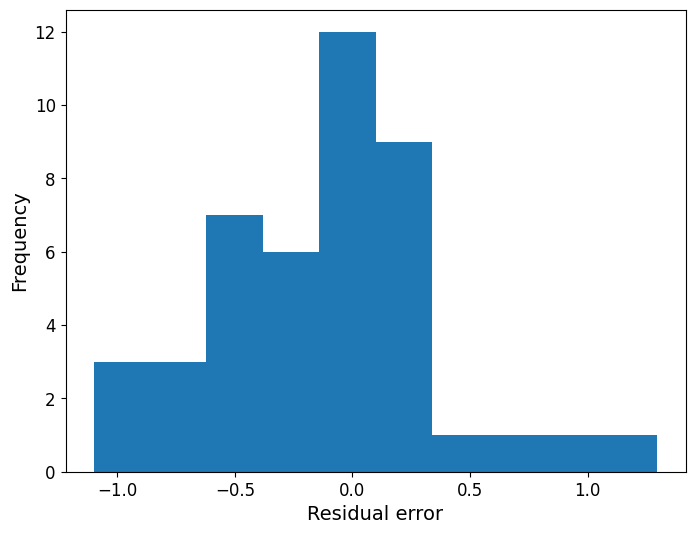

In [ ]:
# Plot residual error

plt.figure(figsize=(8,6))
plt.hist(errors)
plt.xlabel("Residual error", fontsize = 14)
plt.ylabel("Frequency", fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

Now, asset details are pulled out for the three worst and best predictions.

In [ ]:
errors

,Time-to-failure
0,-0.400390
5,-0.019030
10,0.975342
15,0.326027
20,0.309589
25,0.113753
30,-0.026231
35,-0.546456
40,0.304110
45,-0.319067


In [ ]:
# assets with worst residual errors

print(X_train_sequential.iloc[65,])
print(X_train_sequential.iloc[110, ])
print(X_test_sequential.iloc[145, ])

Material             Ductile_Iron
Diameter                 0.091719
Length                   -0.56926
Lining                    PRESENT
Surface                     Rural
Soil               Alluvial soils
Soil_pH                  -0.64158
Frost_days              -0.137663
Hydrogen Ion             0.975321
Free chlorine             1.15446
Previous bursts          2.103867
Age                     -0.072101
Name: 65, dtype: object


In [ ]:
# assets with best residual errors

print(X_test_sequential.iloc[200,])
print(X_test_sequential.iloc[185,])
print(X_test_sequential.iloc[165,])

,200
Asset.ID,6190733
Material,Asbestos_Cement
Diameter,152.4
Length,3121.954897
Lining,NOT_PRESENT
Surface,Rural
Soil,Rankers
Soil_pH,5.3
Frost_days,127.586001
Hydrogen Ion,8.35
